## Detecting and Handling Outliers with DBSCAN

In this notebook, we will identify outliers in the dataset using the DBSCAN algorithm and handle them through interpolation.
We will consider only the accelerometer and gyroscope columns.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from helper.tools import OutlierDetection
# plot settings
%matplotlib inline
plt.style.use('fivethirtyeight')
plt.rcParams["figure.figsize"] = (20, 5)
plt.rcParams["figure.dpi"] = 100

In [17]:
# Load the data
df = pd.read_csv('../initial_data/data.csv')
df.columns

Index(['epoch (ms)', 'Accelerometer_x', 'Accelerometer_y', 'Accelerometer_z',
       'Gyroscope_x', 'Gyroscope_y', 'Gyroscope_z', 'Participants', 'Label',
       'Category', 'Set'],
      dtype='object')

In [18]:
outliers_cols = list(df.columns[1:7])
outliers_cols

['Accelerometer_x',
 'Accelerometer_y',
 'Accelerometer_z',
 'Gyroscope_x',
 'Gyroscope_y',
 'Gyroscope_z']

#### BOXPLOT

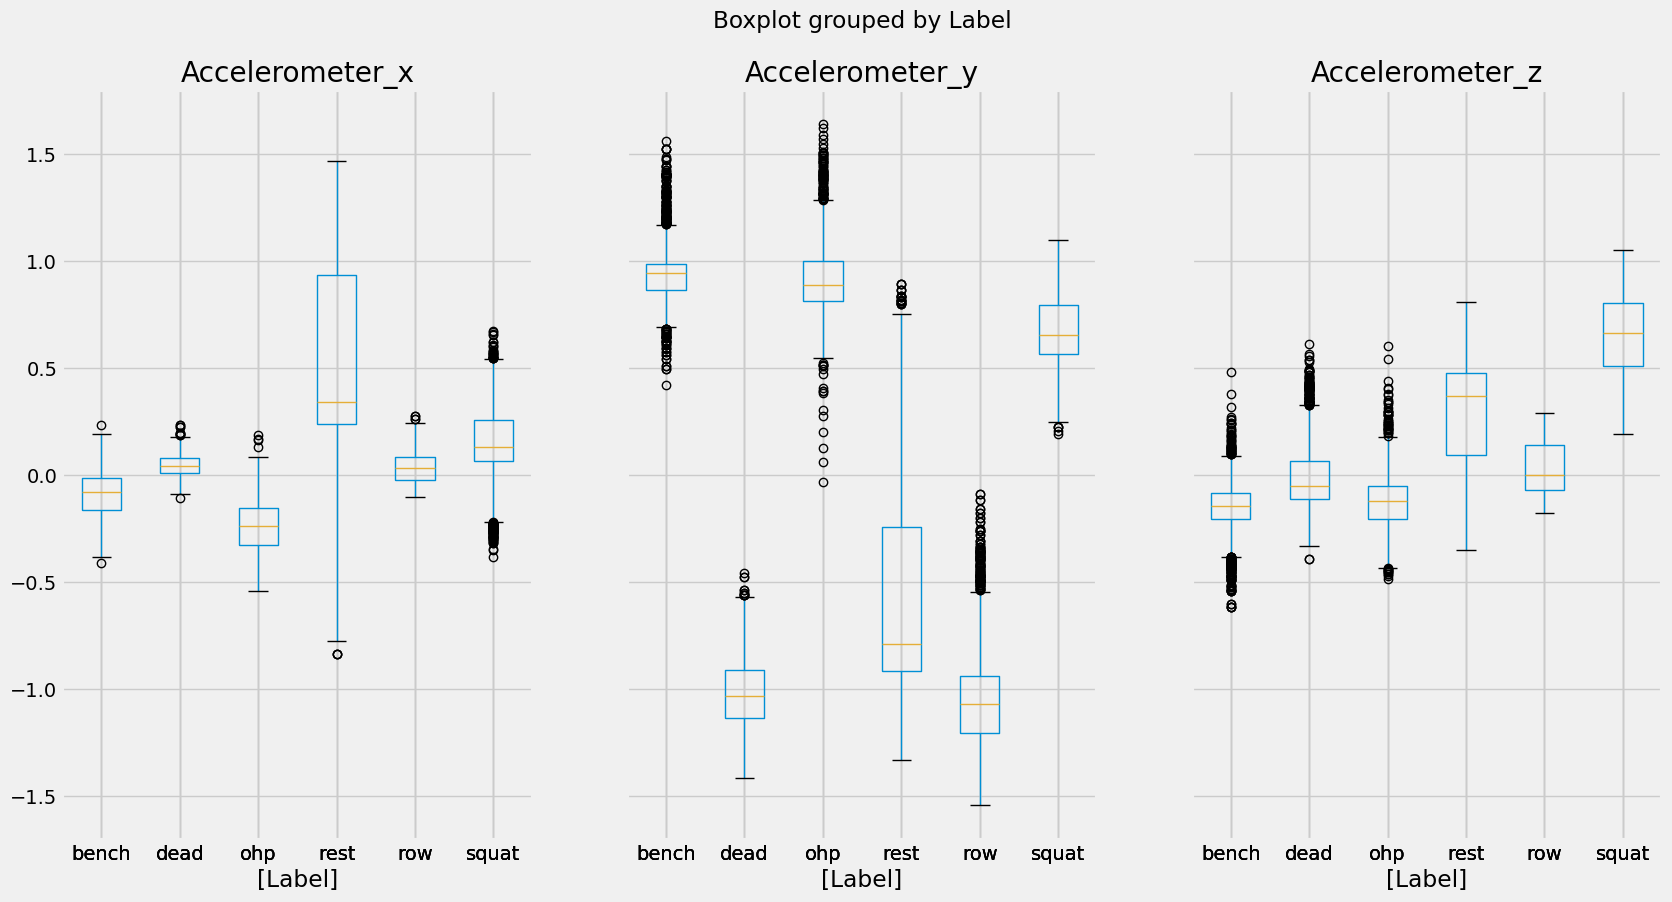

In [19]:
# accelerator data 
df[outliers_cols[:3] + ["Label"]].boxplot(by="Label", figsize = (20, 10), layout = (1, 3))
plt.show()

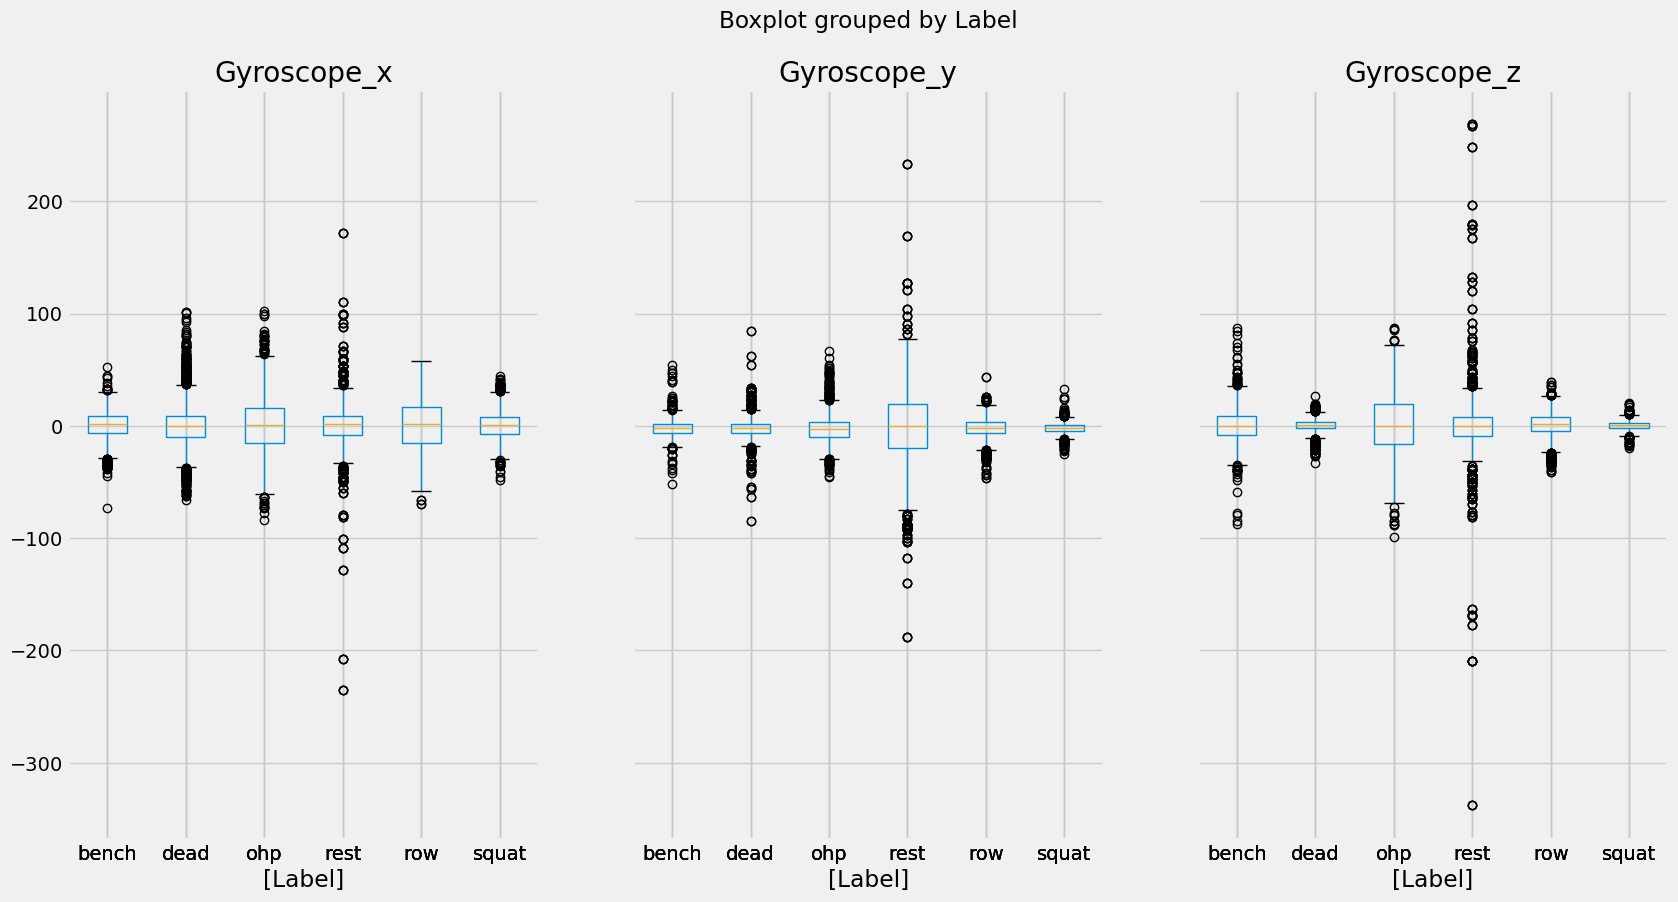

In [20]:
# gyroscope data
df[outliers_cols[3:] + ["Label"]].boxplot(by="Label", figsize = (20, 10), layout = (1, 3))
plt.show()

#### DBSCAN

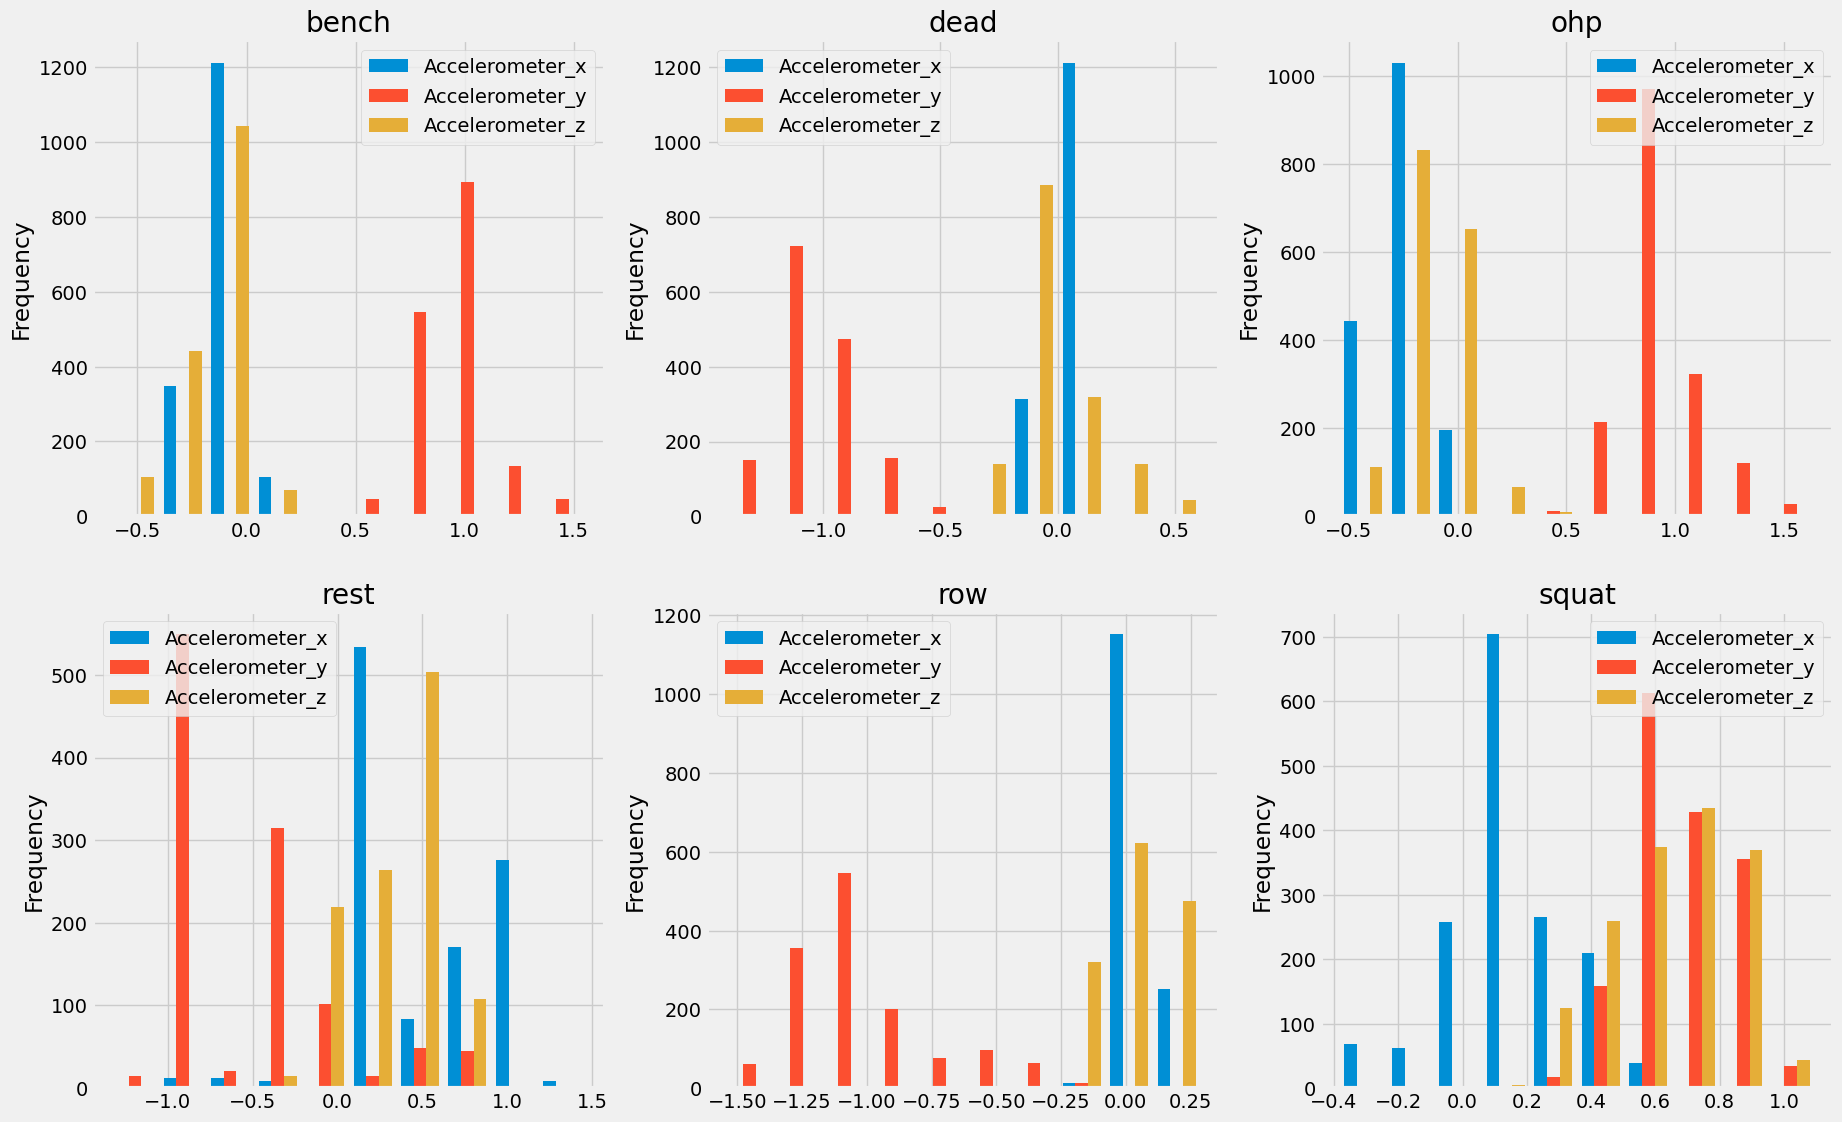

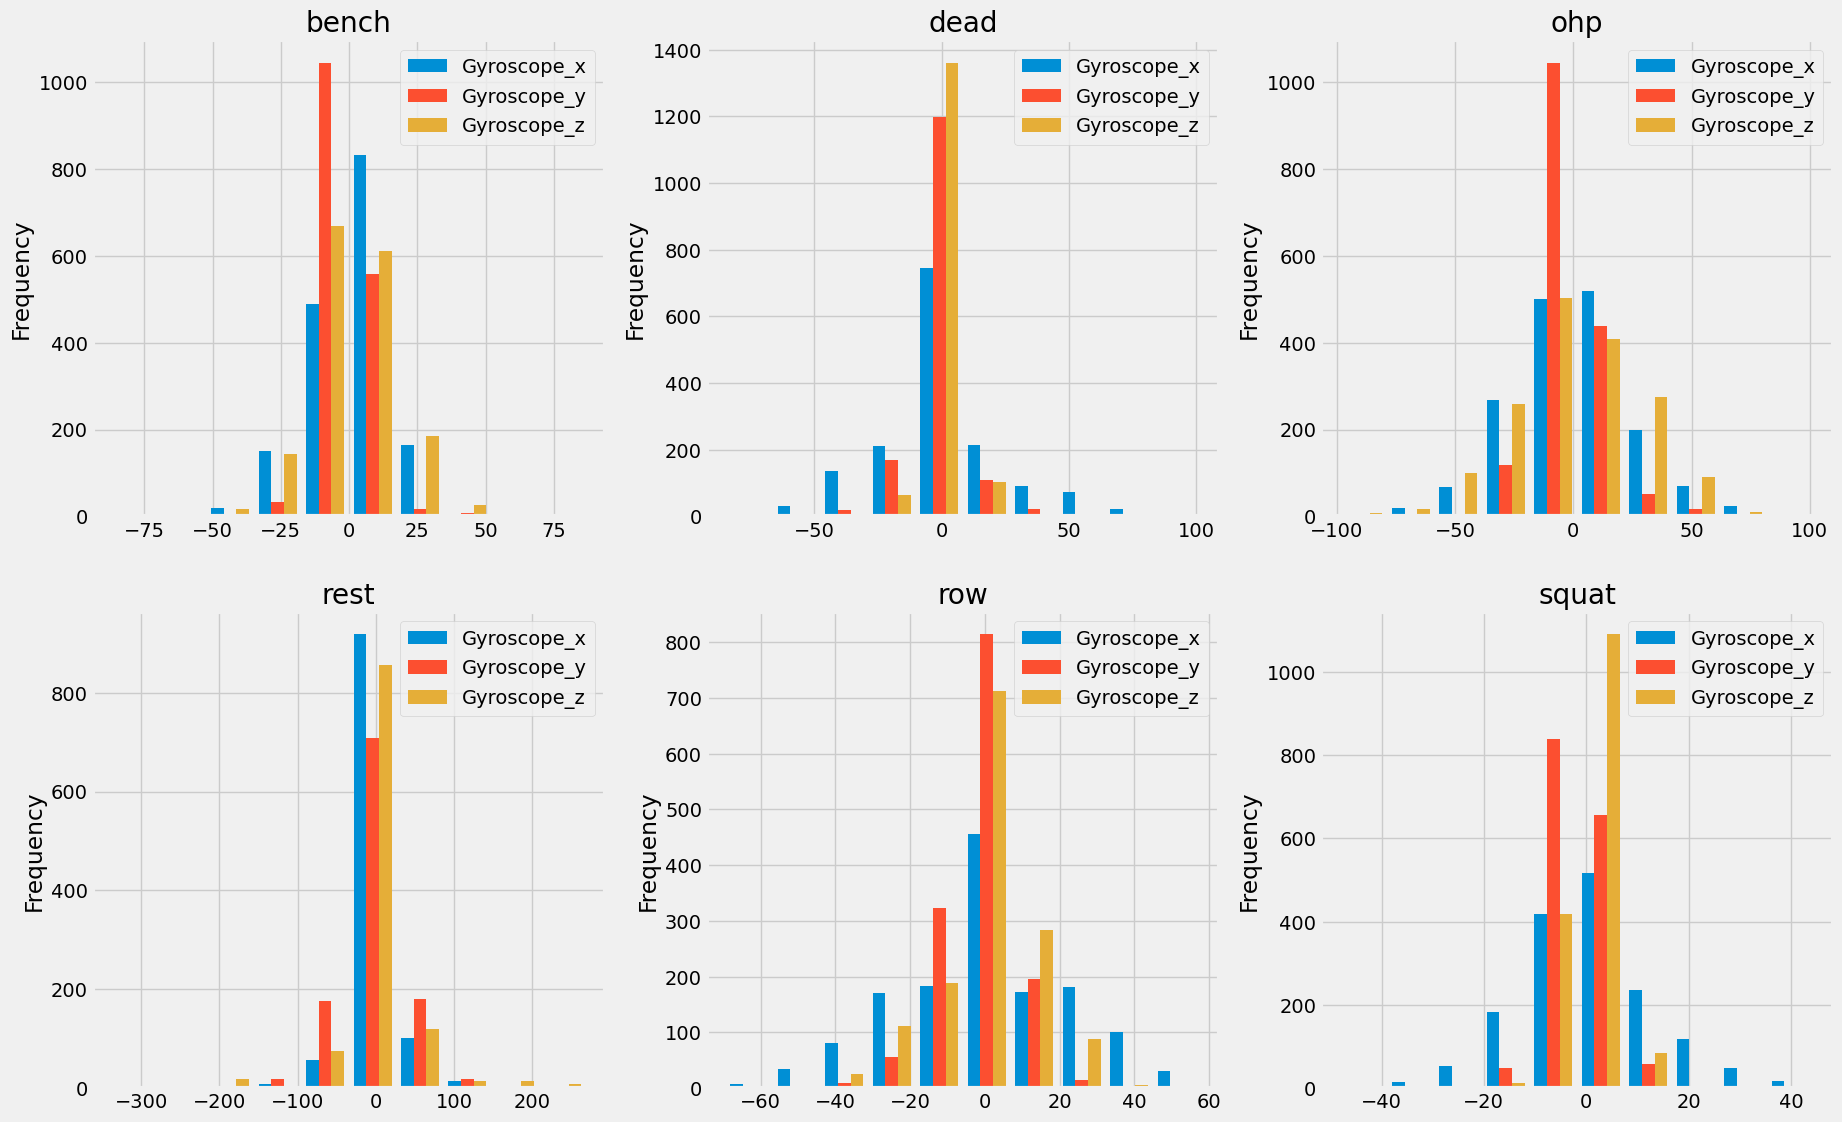

In [21]:
# first let's check the distribution of the data
df[outliers_cols[:3] + ["Label"]].plot.hist(by="Label", figsize = (20, 20), layout = (3, 3))
df[outliers_cols[3:] + ["Label"]].plot.hist(by="Label", figsize = (20, 20), layout = (3, 3))

# show the histogram of the data
plt.show()

In [22]:
# class 
od = OutlierDetection()

In [23]:
# check the normal distribution
od.check_normal_distribution(df, outliers_cols)

Accelerometer_x is not normally distributed (p-value: 0.0)
Accelerometer_y is not normally distributed (p-value: 0.0)
Accelerometer_z is not normally distributed (p-value: 4.924779460496606e-188)
Gyroscope_x is not normally distributed (p-value: 0.0)
Gyroscope_y is not normally distributed (p-value: 0.0)
Gyroscope_z is not normally distributed (p-value: 0.0)


In [24]:
# finding the best eps and min_samples
best_eps, best_min_samples, df_scaled = od.tune_dbscan(df, outliers_cols)

Best DBSCAN parameters: eps = 1.9000000000000001, min_samples = 5
Number of outliers with these parameters: 114


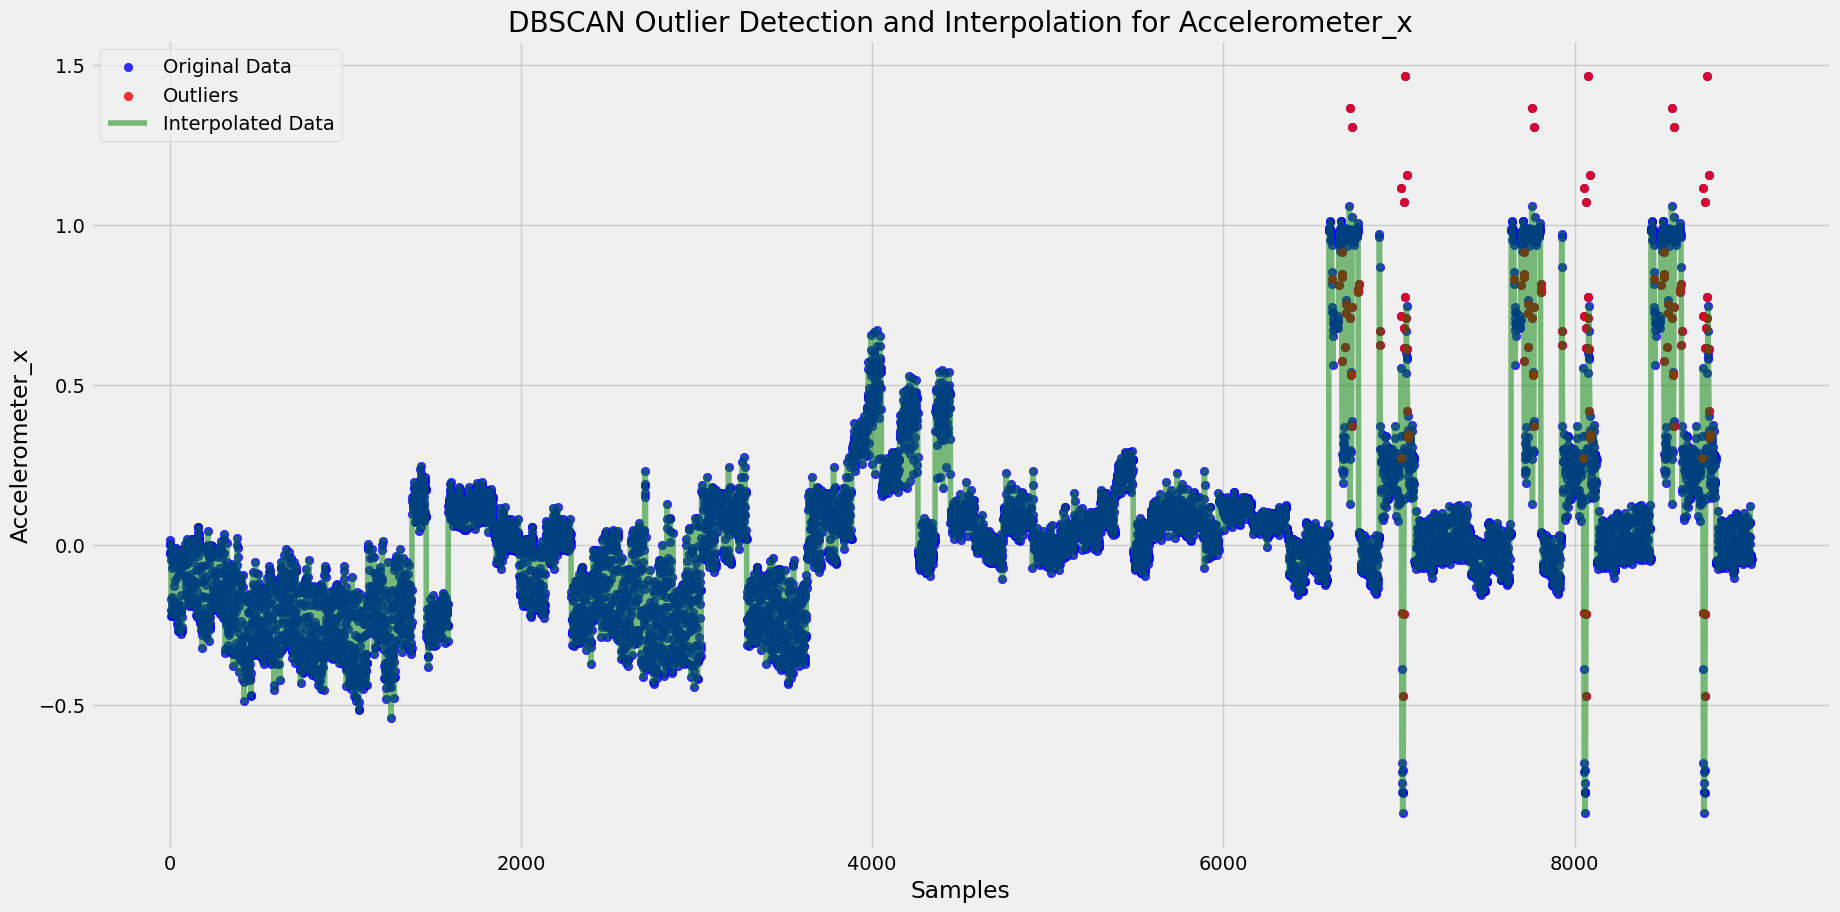

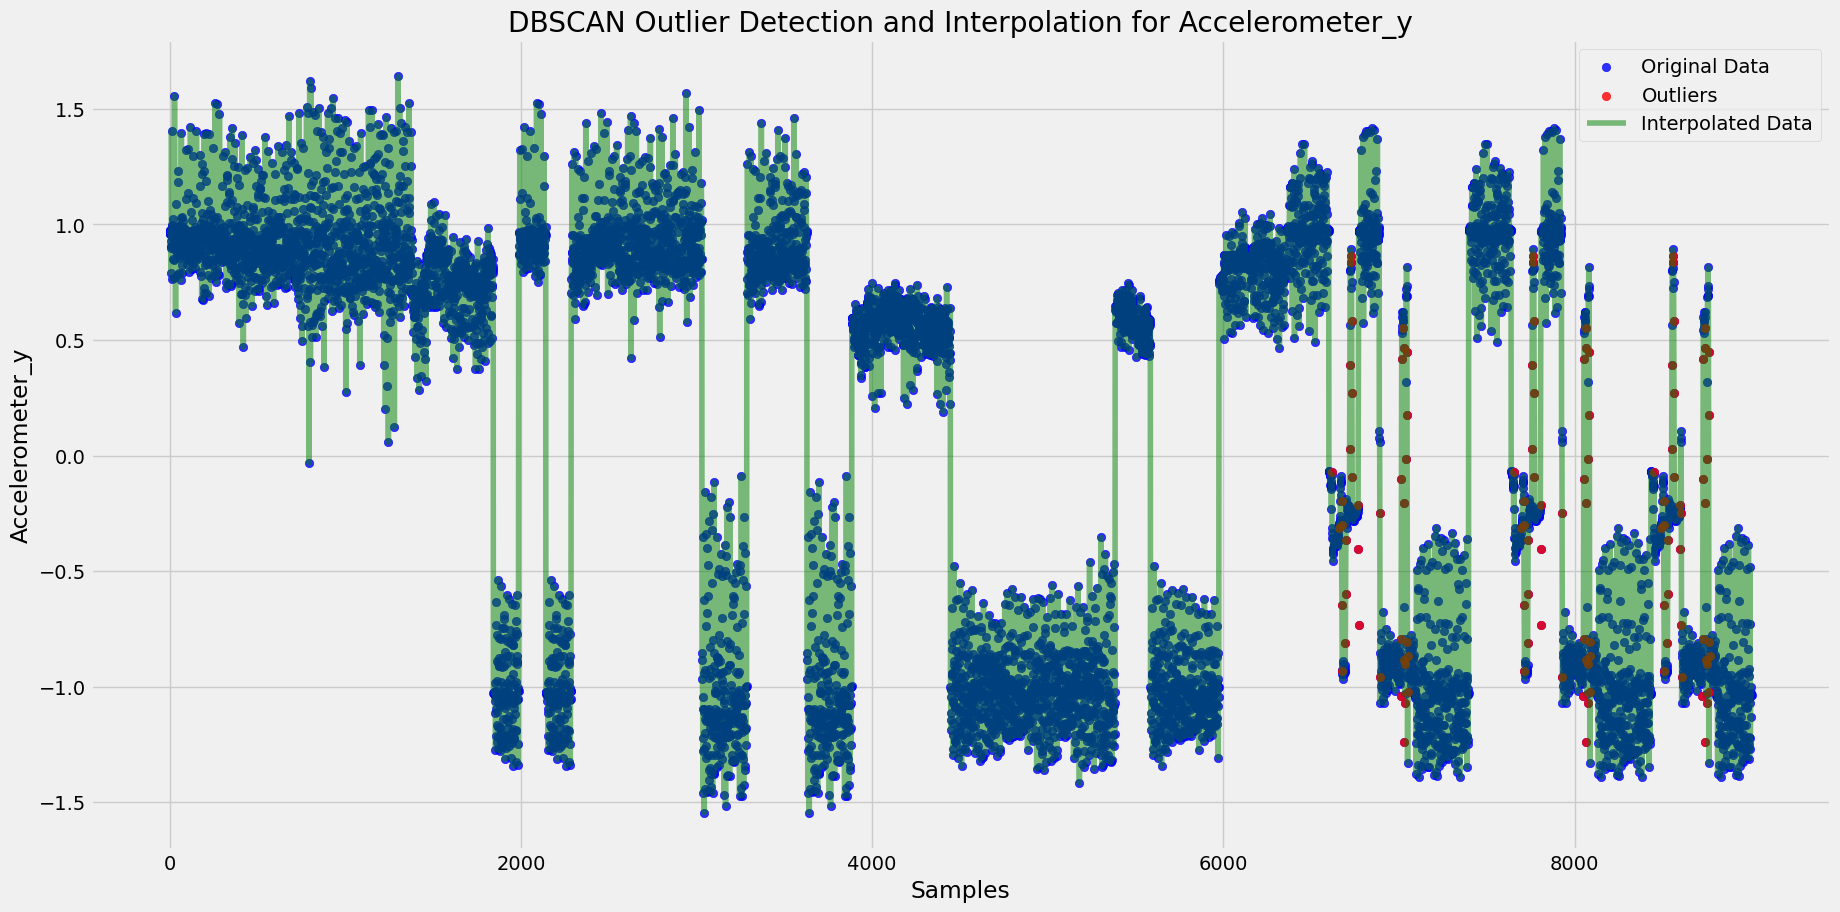

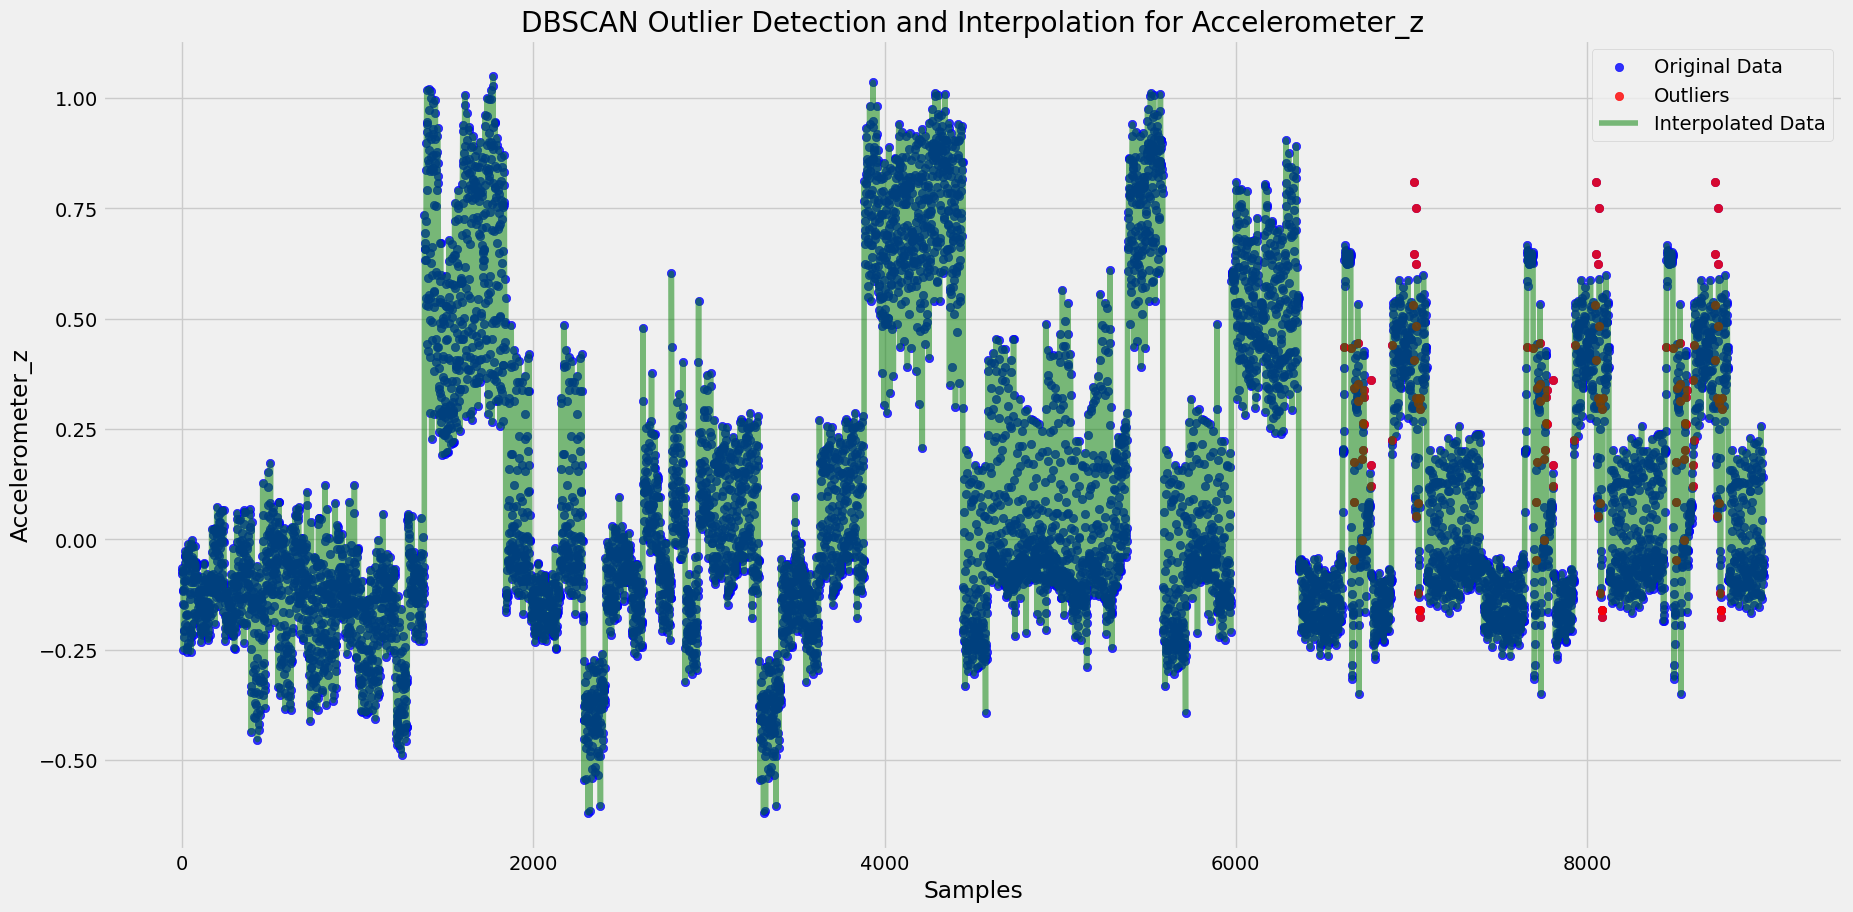

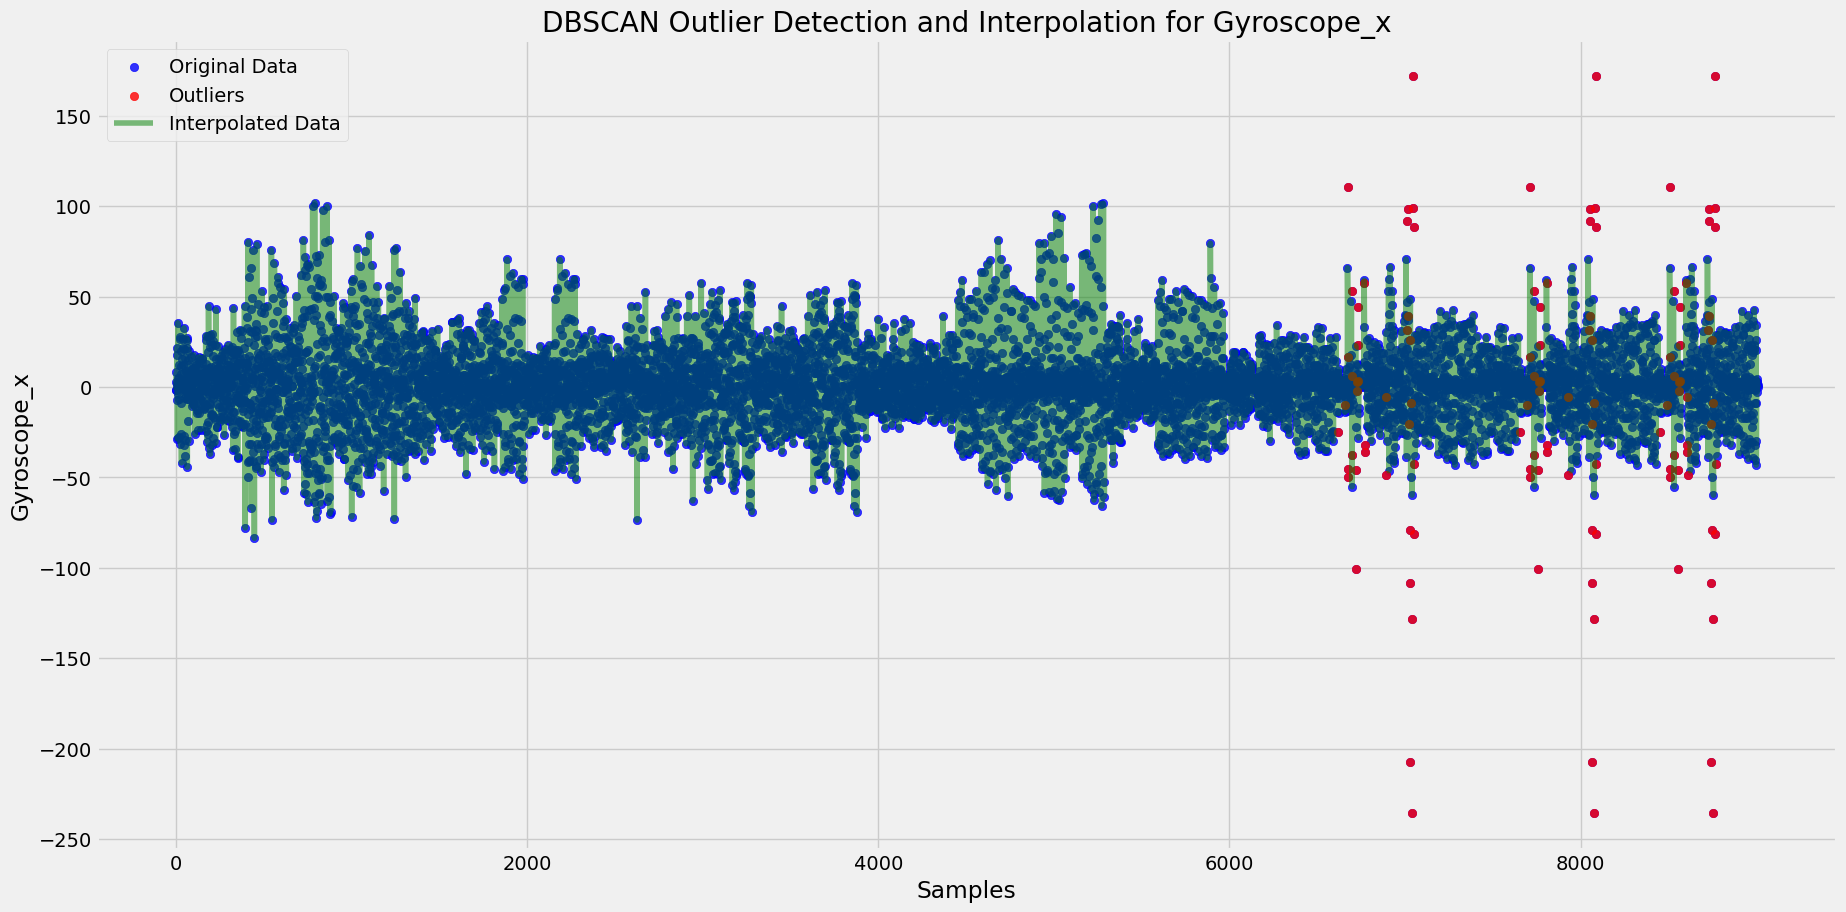

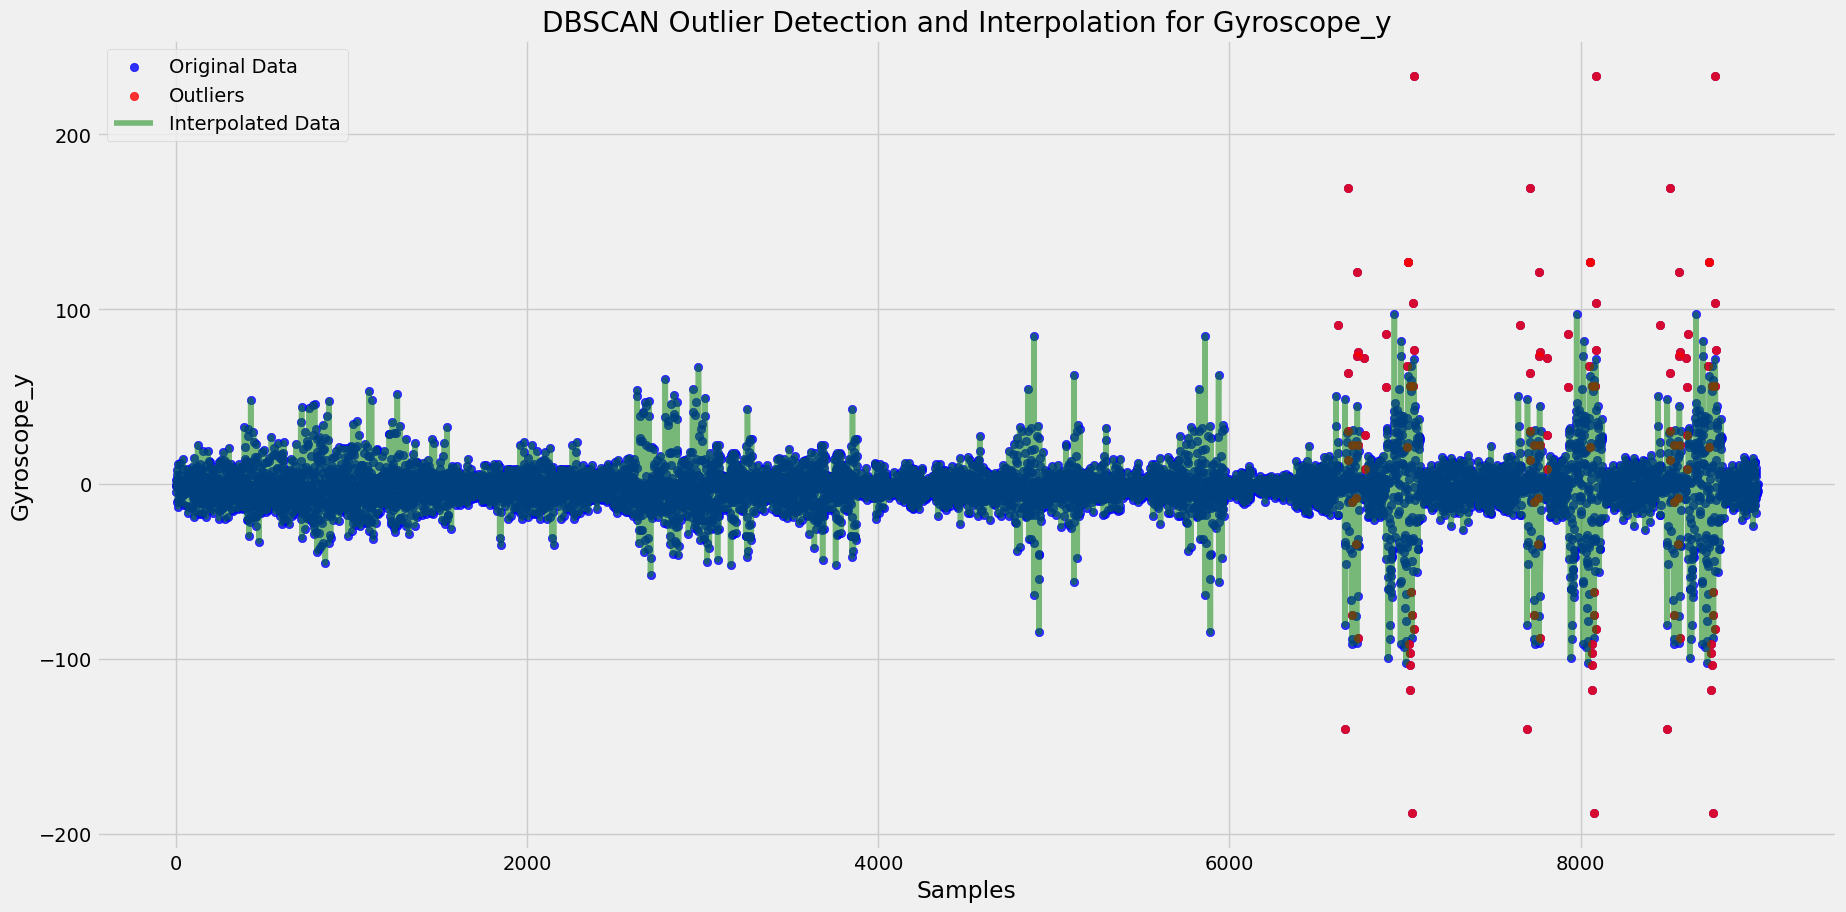

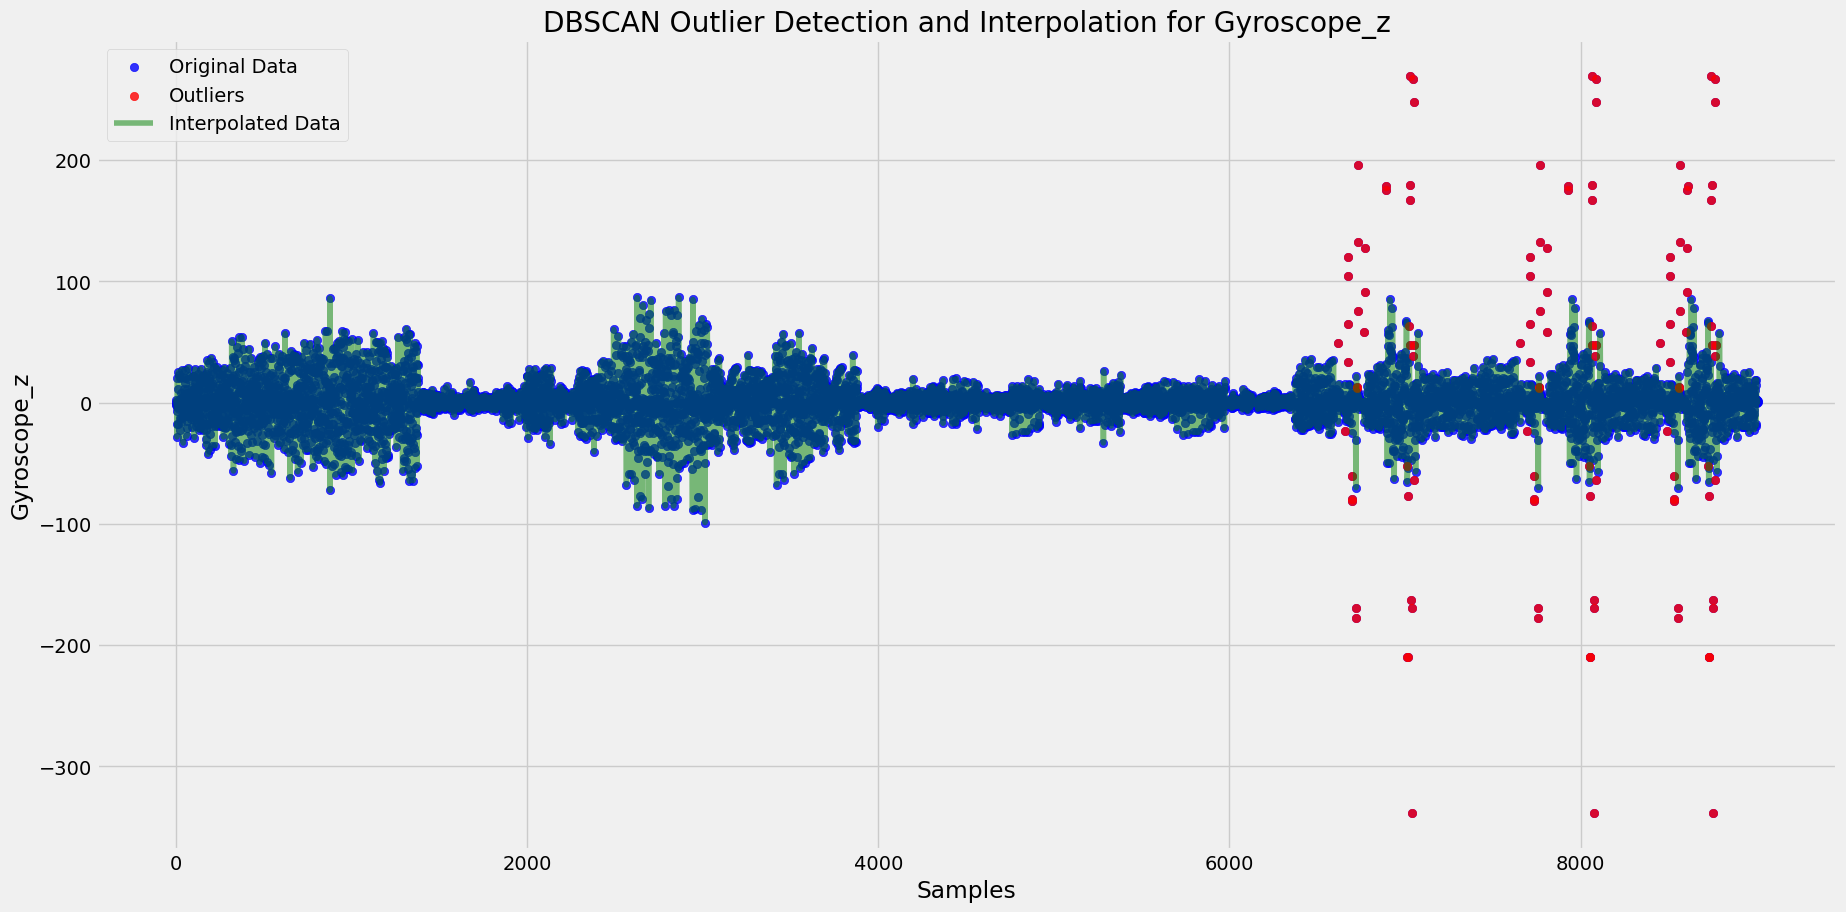

In [25]:

# Apply DBSCAN with the best hyperparameters
dbscan = DBSCAN(eps=best_eps, min_samples=best_min_samples)
outlier_labels = dbscan.fit_predict(df_scaled[outliers_cols])
    
# Outliers
outliers = df[outlier_labels == -1]
    
df_interpolated = df.copy()
for col in outliers_cols:
    # Interpolating the outliers
    df_interpolated[col] = df[col].where(outlier_labels != -1).interpolate(method='linear')
    
# Plot the outliers and interpolated data
for col in outliers_cols:
    plt.figure(figsize=(20, 10))
    
    # Plot original data with outliers
    plt.scatter(df.index, df[col], c='blue', label='Original Data', alpha=0.8)
    plt.scatter(outliers.index, outliers[col], c='red', label='Outliers', alpha=0.8)
    
    # Plot interpolated data
    plt.plot(df_interpolated.index, df_interpolated[col], c='green', label='Interpolated Data', alpha=0.5)
    
    plt.xlabel('Samples')
    plt.ylabel(col)
    plt.title(f'DBSCAN Outlier Detection and Interpolation for {col}')
    plt.legend()
    plt.show()

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9009 entries, 0 to 9008
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   epoch (ms)       9009 non-null   object 
 1   Accelerometer_x  9009 non-null   float64
 2   Accelerometer_y  9009 non-null   float64
 3   Accelerometer_z  9009 non-null   float64
 4   Gyroscope_x      9009 non-null   float64
 5   Gyroscope_y      9009 non-null   float64
 6   Gyroscope_z      9009 non-null   float64
 7   Participants     9009 non-null   object 
 8   Label            9009 non-null   object 
 9   Category         9009 non-null   object 
 10  Set              9009 non-null   int64  
dtypes: float64(6), int64(1), object(4)
memory usage: 774.3+ KB


In [28]:
df_interpolated.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9009 entries, 0 to 9008
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   epoch (ms)       9009 non-null   object 
 1   Accelerometer_x  9009 non-null   float64
 2   Accelerometer_y  9009 non-null   float64
 3   Accelerometer_z  9009 non-null   float64
 4   Gyroscope_x      9009 non-null   float64
 5   Gyroscope_y      9009 non-null   float64
 6   Gyroscope_z      9009 non-null   float64
 7   Participants     9009 non-null   object 
 8   Label            9009 non-null   object 
 9   Category         9009 non-null   object 
 10  Set              9009 non-null   int64  
dtypes: float64(6), int64(1), object(4)
memory usage: 774.3+ KB


In [29]:
# save the interpolated data
#df_interpolated.to_pickle('../processed_data/dataInterpolated.pkl')